<a href="https://colab.research.google.com/github/h3692/company-buying-decision/blob/main/k_means_focus_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer

sns.set_theme(style="whitegrid")
df_unmodified = pd.read_csv("pipeline_results.csv")
df_unmodified.head()

,Canonical ID [canonical_id],Company Name [canonical_name],Company Query [company_query],Industry [industry],NAICS Code [naics],SIC Code [sic],Employee Count [employee_count],Employee Range [employee_range],Revenue [revenue],Revenue Range [revenue_range],HQ City [hq_city],HQ State / Region [hq_region],HQ Country [hq_country],Year Founded [year_founded],Ownership Type [public_private],Number of Locations [number_of_locations],Parent Company [parent_company],Stock Ticker [stock_ticker],Employee Count Source [employee_source],Revenue Source [revenue_source],Firmographic Conflict Flag [firmographic_conflict_flag],Total Tech Tools [total_tech_count],Tech Complexity Score [tech_stack_complexity_score],Cloud Platforms [cloud_platforms],Endpoint Management Tools [endpoint_management],Virtualization Tools [virtualization_tools],Infrastructure Software [infrastructure_software],Processor Flag Amd Pro [processor_flag_amd_pro],Processor Flag Intel Vpro [processor_flag_intel_vpro],Tech Coverage Pct [tech_coverage_pct],Tech Enrichment Status [tech_enrichment_status],Company Summary [company_summary],Company Headline [company_headline],Keywords [keywords],Intent Topics [intent_topics],Intent Strength Score [intent_strength_score],Active Research Areas [active_research_categories],Top Intent Topic [top_intent_topic],Open Job Postings [job_postings_count],Hiring Scoops (ZoomInfo) [hiring_scoops],...,Product / Launch Scoops (ZoomInfo) [product_scoops],Employee Growth Rate [employee_growth_rate],Alexa Web Ranking [alexa_ranking],Intent Data Available [show_intent],News Mentions [news_mentions_count],Most Recent News [most_recent_news],All News Articles [news_articles],Total Funding Raised [total_funding_raised],Last Funding Date [last_funding_date],Latest Funding Stage [latest_funding_stage],Number of Funding Rounds [number_funding_rounds],Funding Stage History [funding_stages],Funding Events [funding_events],Funding Events Count [funding_events_count],M&A Signals [m_and_a_signals],Leadership Changes [leadership_changes],Most Recent Trigger Event [most_recent_trigger_event],Most Recent Signal Date [most_recent_signal_date],Signal Recency Score [signal_recency],Total Signals [signal_count_total],Signal Strength Score [signal_strength_score],Signal Data Sources [signal_source_mix],Employees per Location [employee_location_ratio],Hiring Velocity [hiring_velocity],Infrastructure Maturity Score [infrastructure_maturity],Endpoint Density [endpoint_density_proxy],Industry One Hot [industry_one_hot],Tech Stack Binary Flags [tech_stack_binary_flags],Match Score [match_score],Resolution Status [resolution_status],Government / National Lab [gov_lab_flag],ZoomInfo ID [zoominfo_company_id],Apollo ID [apollo_org_id],PDL ID [pdl_company_id],Normalized Name [normalized_name],Domain [domain],Legal Suffix Removed [suffix_removed_flag],Data Completeness Score [data_completeness_score],Ready For Analysis Flag [ready_for_analysis_flag],Exported At [exported_at]
0,ap_5da3d58603225e0001ec5f03,"beBOLD Digital - Full-Service Amazon, Walmart ...","Walmart, Inc.",marketing & advertising,54161.0,7375.0,25.0,NaN,NaN,NaN,Bentonville,Arkansas,United States,2017.0,private,0.0,NaN,NaN,apollo,NaN,Yes,0,0.0000,NaN,NaN,NaN,NaN,No,No,0.0,missing,NaN,NaN,amazon consultant; vendor central; amazon acco...,NaN,0.0000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0.002732,0,0.0003,none,25.00,0.0,0.000000,0.0000,Other,none,0.00,unresolved,No,NaN,5da3d58603225e0001ec5f03,NaN,bebold digital full service amazon walmart soc...,bebolddigital.com,Yes,52.5,Yes,2026-03-18T07:57:57.121646+00:00
1,zi_14980551,Argonne National Laboratory,Argonne National Laboratory,"Government, Federal",54171.0,8711.0,3569.0,"1,000 - 5,000",1.200000e+08,$500 mil. - $1 bil.,Lemont,Illinois,United States,1946.0,private,9.0,US Department of Energy,NaN,zoominfo,zoominfo,Yes,551,93.1355,Amazon AWS; Microsoft Azure,JAMF Pro,VMware vFabric; VMware ESX Server; Ceph; Cisco...,Produ

In [2]:
df_unmodified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 83 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Canonical ID [canonical_id]                              126 non-null    object 
 1   Company Name [canonical_name]                            126 non-null    object 
 2   Company Query [company_query]                            126 non-null    object 
 3   Industry [industry]                                      122 non-null    object 
 4   NAICS Code [naics]                                       43 non-null     float64
 5   SIC Code [sic]                                           50 non-null     float64
 6   Employee Count [employee_count]                          122 non-null    float64
 7   Employee Range [employee_range]                          119 non-null    object 
 8   Revenue [revenue]             

In [3]:
df_compressed = pd.read_csv("pipeline_results.csv", usecols=["Company Name [canonical_name]", "Industry [industry]", "Employee Count [employee_count]", "Revenue [revenue]", "HQ State / Region [hq_region]", "Year Founded [year_founded]", "Ownership Type [public_private]", "Number of Locations [number_of_locations]", "Total Tech Tools [total_tech_count]", "Tech Complexity Score [tech_stack_complexity_score]", "Infrastructure Maturity Score [infrastructure_maturity]", "Endpoint Density [endpoint_density_proxy]", "Employees per Location [employee_location_ratio]", "Government / National Lab [gov_lab_flag]"])
df_compressed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 14 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      122 non-null    object 
 2   Employee Count [employee_count]                          122 non-null    float64
 3   Revenue [revenue]                                        120 non-null    float64
 4   HQ State / Region [hq_region]                            125 non-null    object 
 5   Year Founded [year_founded]                              121 non-null    float64
 6   Ownership Type [public_private]                          125 non-null    object 
 7   Number of Locations [number_of_locations]                122 non-null    float64
 8   Total Tech Tools [total_tech_c

In [4]:
from sklearn.impute import SimpleImputer

num_cols = [
    "Employee Count [employee_count]",
    "Revenue [revenue]",
    "Year Founded [year_founded]",
    "Number of Locations [number_of_locations]",
]

cat_cols = [
    "Industry [industry]",
    "HQ State / Region [hq_region]",
    "Ownership Type [public_private]",
]

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value="Unknown")

df_compressed[num_cols] = num_imputer.fit_transform(df_compressed[num_cols])
df_compressed[cat_cols] = cat_imputer.fit_transform(df_compressed[cat_cols])

df_compressed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 14 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

In [5]:
tech_cols = ["Total Tech Tools [total_tech_count]", "Tech Complexity Score [tech_stack_complexity_score]"]
tech_scaler = StandardScaler()
tech_pca = PCA(n_components=1)

tech_scaled_train = tech_scaler.fit_transform(df_compressed[tech_cols].fillna(0))
df_compressed['PCA_Tech_Maturity'] = tech_pca.fit_transform(tech_scaled_train)
df_compressed.info()
print(f"Variance captured by PCA: {tech_pca.explained_variance_ratio_[0]:.2%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 15 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

In [6]:
df_compressed.head()

,Company Name [canonical_name],Industry [industry],Employee Count [employee_count],Revenue [revenue],HQ State / Region [hq_region],Year Founded [year_founded],Ownership Type [public_private],Number of Locations [number_of_locations],Total Tech Tools [total_tech_count],Tech Complexity Score [tech_stack_complexity_score],Employees per Location [employee_location_ratio],Infrastructure Maturity Score [infrastructure_maturity],Endpoint Density [endpoint_density_proxy],Government / National Lab [gov_lab_flag],PCA_Tech_Maturity
0,"beBOLD Digital - Full-Service Amazon, Walmart ...",marketing & advertising,25.0,7.405150e+07,Arkansas,2017.0,private,0.0,0,0.0000,25.00,0.000000,0.0000,No,-3.362590
1,Argonne National Laboratory,"Government, Federal",3569.0,1.200000e+08,Illinois,1946.0,private,9.0,551,93.1355,396.56,0.733333,0.2802,Yes,-0.511582
2,Cohesity,"Software, Storage & System Management Software",4275.0,8.979710e+05,California,2013.0,private,2.0,405,90.0635,2137.50,0.900000,0.2339,No,-0.705552
3,GE Vernova,"Energy, Utilities & Waste, Electricity, Oil & Gas",75000.0,3.806800e+10,Massachusetts,2022.0,public,1.0,601,94.0026,75000.00,0.900000,0.0133,No,-0.449961
4,GSK,"Manufacturing, Pharmaceuticals",70000.0,4.399180e+07,Greater London,2000.0,PUBLIC,367.0,1938,105.6993,190.74,1.000000,0.1143,No,0.899229


In [8]:
nlp_model = SentenceTransformer('all-MiniLM-L6-v2')
df_industries = df_compressed['Industry [industry]'].tolist()
df_embeddings = nlp_model.encode(df_industries)

industry_pca = PCA(n_components=5)
df_industries_vecs = industry_pca.fit_transform(df_embeddings)

for i in range(5):
  df_compressed[f'Industry_Vec_{i}'] = df_industries_vecs[:, i]

df_compressed.info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 20 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

In [9]:
df_region_coordinates = pd.read_csv("US_GeoCode.csv")
df_region_coordinates.head()

,state&teritory,latitude,longitude,Name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


In [12]:
region_coordinates = dict(
    zip(
        df_region_coordinates['Name'],
        zip(df_region_coordinates['latitude'], df_region_coordinates['longitude'])
    )
)

region_coordinates['Unknown'] = (0.0,0.0)
print("dictionary sample: ", list(region_coordinates.items())[:5])

dictionary sample:  [('Alaska', (63.588753, -154.493062)), ('Alabama', (32.318231, -86.902298)), ('Arkansas', (35.20105, -91.831833)), ('Arizona', (34.048928, -111.093731)), ('California', (36.778261, -119.417932))]


In [14]:
def get_lat_lon(state_name):
  return region_coordinates.get(state_name, (0.0,0.0))

train_coords = df_compressed['HQ State / Region [hq_region]'].apply(get_lat_lon)
df_compressed["HQ_Lat"] = train_coords.apply(lambda x: x[0])
df_compressed["HQ_Lon"] = train_coords.apply(lambda x: x[1])

df_compressed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 22 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

In [15]:
df_compressed.head()

,Company Name [canonical_name],Industry [industry],Employee Count [employee_count],Revenue [revenue],HQ State / Region [hq_region],Year Founded [year_founded],Ownership Type [public_private],Number of Locations [number_of_locations],Total Tech Tools [total_tech_count],Tech Complexity Score [tech_stack_complexity_score],Employees per Location [employee_location_ratio],Infrastructure Maturity Score [infrastructure_maturity],Endpoint Density [endpoint_density_proxy],Government / National Lab [gov_lab_flag],PCA_Tech_Maturity,Industry_Vec_0,Industry_Vec_1,Industry_Vec_2,Industry_Vec_3,Industry_Vec_4,HQ_Lat,HQ_Lon
0,"beBOLD Digital - Full-Service Amazon, Walmart ...",marketing & advertising,25.0,7.405150e+07,Arkansas,2017.0,private,0.0,0,0.0000,25.00,0.000000,0.0000,No,-3.362590,-0.234352,-0.179866,-0.045246,-0.239072,0.134778,35.201050,-91.831833
1,Argonne National Laboratory,"Government, Federal",3569.0,1.200000e+08,Illinois,1946.0,private,9.0,551,93.1355,396.56,0.733333,0.2802,Yes,-0.511582,0.738102,0.010348,-0.081481,0.047467,-0.022789,40.633125,-89.398528
2,Cohesity,"Software, Storage & System Management Software",4275.0,8.979710e+05,California,2013.0,private,2.0,405,90.0635,2137.50,0.900000,0.2339,No,-0.705552,-0.222263,-0.235528,-0.160250,0.193330,-0.384585,36.778261,-119.417932
3,GE Vernova,"Energy, Utilities & Waste, Electricity, Oil & Gas",75000.0,3.806800e+10,Massachusetts,2022.0,public,1.0,601,94.0026,75000.00,0.900000,0.0133,No,-0.449961,0.030184,-0.055648,-0.142797,0.059735,0.000310,42.407211,-71.382437
4,GSK,"Manufacturing, Pharmaceuticals",70000.0,4.399180e+07,Greater London,2000.0,PUBLIC,367.0,1938,105.6993,190.74,1.000000,0.1143,No,0.899229,-0.231939,-0.268319,-0.075190,0.348077,0.219469,0.000000,0.000000


In [31]:
from sklearn.preprocessing import OneHotEncoder

mapping_dict = {"Yes": 1, "No": 0}
df_compressed["Gov_Lab_Numeric"] = df_compressed["Government / National Lab [gov_lab_flag]"].map(mapping_dict).fillna(0)

df_compressed["Ownership Type [public_private]"] = df_compressed["Ownership Type [public_private]"].str.strip().str.lower()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train_array = encoder.fit_transform(df_compressed[["Ownership Type [public_private]"]])
encoded_col_names = encoder.get_feature_names_out(["Ownership Type [public_private]"])

df_encoded = pd.DataFrame(encoded_train_array, columns=encoded_col_names, index=df_compressed.index)
df_compressed = pd.concat([df_compressed, df_encoded], axis=1)

df_compressed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 26 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

In [30]:
df_compressed = df_compressed.drop(df_compressed.columns[[23,24,25,26,27,28,29]], axis=1)
df_compressed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 23 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

In [35]:
df_compressed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 26 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Company Name [canonical_name]                            126 non-null    object 
 1   Industry [industry]                                      126 non-null    object 
 2   Employee Count [employee_count]                          126 non-null    float64
 3   Revenue [revenue]                                        126 non-null    float64
 4   HQ State / Region [hq_region]                            126 non-null    object 
 5   Year Founded [year_founded]                              126 non-null    float64
 6   Ownership Type [public_private]                          126 non-null    object 
 7   Number of Locations [number_of_locations]                126 non-null    float64
 8   Total Tech Tools [total_tech_c

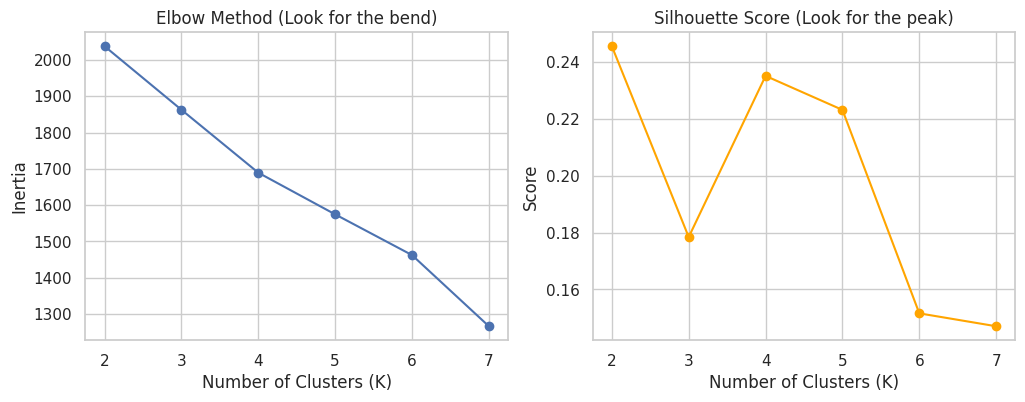

In [40]:
final_features = [
    "Employee Count [employee_count]",
    "Revenue [revenue]",
    "Year Founded [year_founded]",
    "Number of Locations [number_of_locations]",
    "Employees per Location [employee_location_ratio]",
    "Infrastructure Maturity Score [infrastructure_maturity]",
    "Endpoint Density [endpoint_density_proxy]",
    "PCA_Tech_Maturity",
    "Industry_Vec_0",
    "Industry_Vec_1",
    "Industry_Vec_2",
    "Industry_Vec_3",
    "Industry_Vec_4",
    "HQ_Lat",
    "HQ_Lon",
    "Gov_Lab_Numeric",
    "Ownership Type [public_private]_private",
    "Ownership Type [public_private]_public",
    "Ownership Type [public_private]_unknown"
]

master_scaler = StandardScaler()
X_train_scaled = master_scaler.fit_transform(df_compressed[final_features])

inertia = []
sil_scores = []
K_range = range(2,8)

for k in K_range:
  kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans_eval.fit(X_train_scaled)

  inertia.append(kmeans_eval.inertia_)
  sil_scores.append(silhouette_score(X_train_scaled, kmeans_eval.labels_))

fig, ax = plt.subplots(1,2, figsize=(12,4))

# Chart 1: The Elbow
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Elbow Method (Look for the bend)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')

# Chart 2: The Silhouette
ax[1].plot(K_range, sil_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Score (Look for the peak)')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Score')

plt.show()

In [41]:
OPTIMAL_K = 4

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_compressed["Cluster_ID"] = final_kmeans.fit_predict(X_train_scaled)
df_compressed.head()

,Company Name [canonical_name],Industry [industry],Employee Count [employee_count],Revenue [revenue],HQ State / Region [hq_region],Year Founded [year_founded],Ownership Type [public_private],Number of Locations [number_of_locations],Total Tech Tools [total_tech_count],Tech Complexity Score [tech_stack_complexity_score],Employees per Location [employee_location_ratio],Infrastructure Maturity Score [infrastructure_maturity],Endpoint Density [endpoint_density_proxy],Government / National Lab [gov_lab_flag],PCA_Tech_Maturity,Industry_Vec_0,Industry_Vec_1,Industry_Vec_2,Industry_Vec_3,Industry_Vec_4,HQ_Lat,HQ_Lon,Gov_Lab_Numeric,Ownership Type [public_private]_private,Ownership Type [public_private]_public,Ownership Type [public_private]_unknown,Cluster_ID
0,"beBOLD Digital - Full-Service Amazon, Walmart ...",marketing & advertising,25.0,7.405150e+07,Arkansas,2017.0,private,0.0,0,0.0000,25.00,0.000000,0.0000,No,-3.362590,-0.234352,-0.179866,-0.045246,-0.239072,0.134778,35.201050,-91.831833,0,1.0,0.0,0.0,1
1,Argonne National Laboratory,"Government, Federal",3569.0,1.200000e+08,Illinois,1946.0,private,9.0,551,93.1355,396.56,0.733333,0.2802,Yes,-0.511582,0.738102,0.010348,-0.081481,0.047467,-0.022789,40.633125,-89.398528,1,1.0,0.0,0.0,3
2,Cohesity,"Software, Storage & System Management Software",4275.0,8.979710e+05,California,2013.0,private,2.0,405,90.0635,2137.50,0.900000,0.2339,No,-0.705552,-0.222263,-0.235528,-0.160250,0.193330,-0.384585,36.778261,-119.417932,0,1.0,0.0,0.0,3
3,GE Vernova,"Energy, Utilities & Waste, Electricity, Oil & Gas",75000.0,3.806800e+10,Massachusetts,2022.0,public,1.0,601,94.0026,75000.00,0.900000,0.0133,No,-0.449961,0.030184,-0.055648,-0.142797,0.059735,0.000310,42.407211,-71.382437,0,0.0,1.0,0.0,0
4,GSK,"Manufacturing, Pharmaceuticals",70000.0,4.399180e+07,Greater London,2000.0,public,367.0,1938,105.6993,190.74,1.000000,0.1143,No,0.899229,-0.231939,-0.268319,-0.075190,0.348077,0.219469,0.000000,0.000000,0,0.0,1.0,0.0,0


In [46]:
# Grab just the Name and the Cluster ID, and sort them by Cluster
company_list = df_compressed[['Cluster_ID', 'Company Name [canonical_name]', 'Revenue [revenue]', 'Industry [industry]']].copy()
company_list = company_list.sort_values(by='Cluster_ID').reset_index(drop=True)

# Rename columns for presentation
company_list.columns = ['Cluster ID', 'Company', 'Revenue', 'Industry']

# Display the first 50 rows
display(company_list.head(126))
company_list.to_csv('amd_focus_100_clusters.csv', index=False)

,Cluster ID,Company,Revenue,Industry
0,0,GE Vernova,3.806800e+10,"Energy, Utilities & Waste, Electricity, Oil & Gas"
1,0,GSK,4.399180e+07,"Manufacturing, Pharmaceuticals"
2,0,Government of Canada,3.561080e+11,"Government, Federal"
3,0,NASA,1.572000e+09,"Government, Federal"
4,0,Cigna,2.749000e+08,Insurance
...,...,...,...,...
121,3,Epic,5.700000e+06,Healthcare Software
122,3,Hudson River Trading,4.640070e+05,Financial Services
123,3,NBCUniversal,3.672951e+07,"Media & Internet, Broadcasting"
124,3,Kaiser Permanente,1.158000e+08,Hospitals & Physicians Clinics


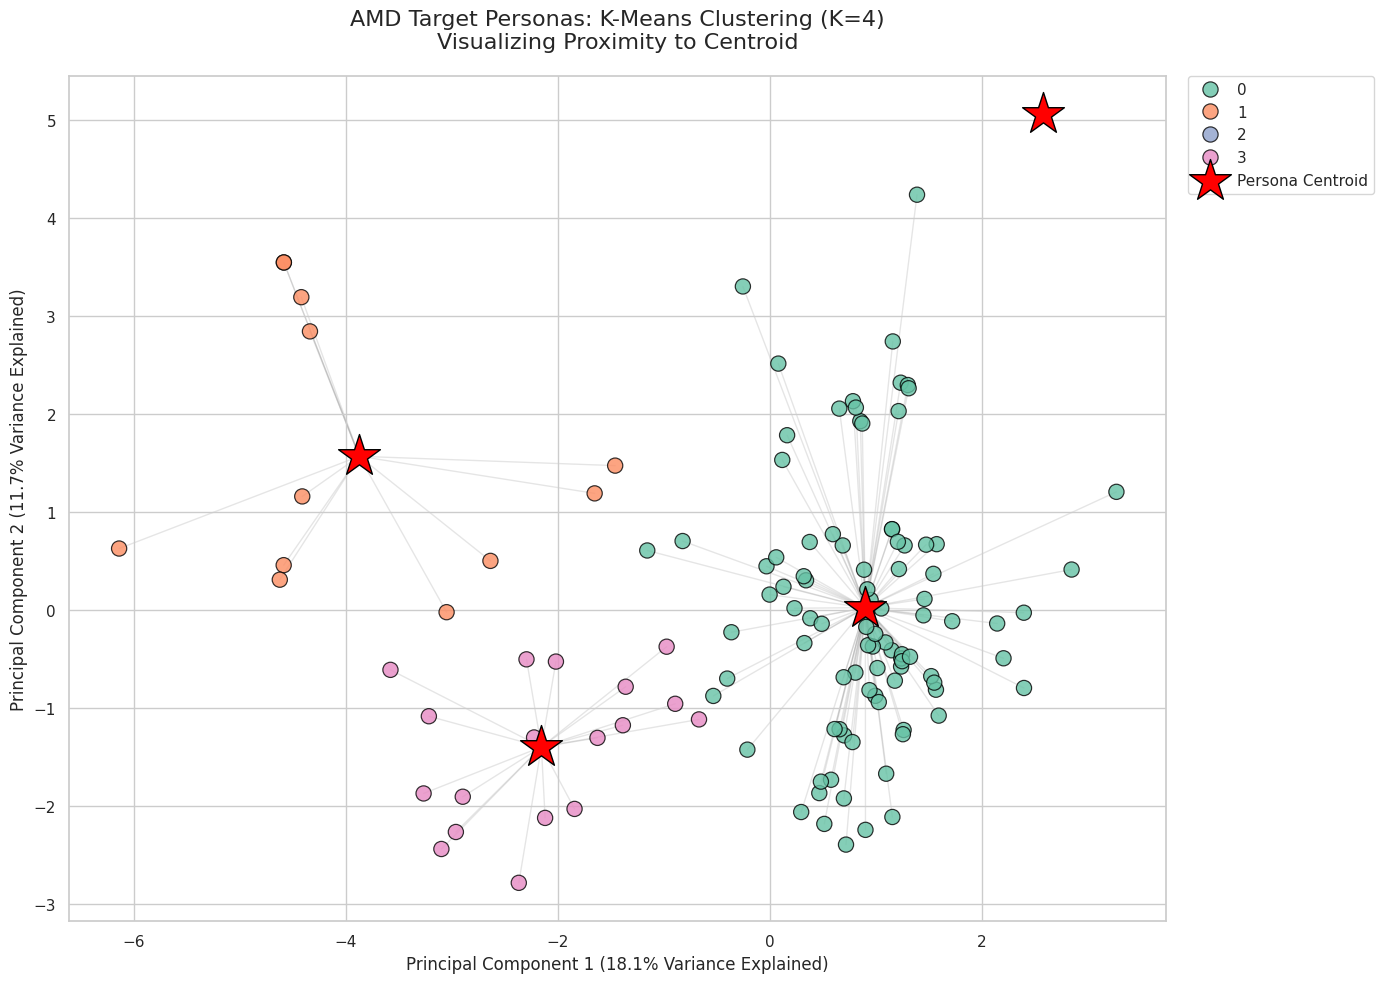

In [47]:
# 1. Compress the 14D scaled data down to 2D for visualization
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

# Squash the centroids down to the exact same 2D map
centroids_2d = pca_2d.transform(final_kmeans.cluster_centers_)

# 2. Add the new X/Y coordinates back to your dataframe for plotting
df_compressed['Plot_X'] = X_train_2d[:, 0]
df_compressed['Plot_Y'] = X_train_2d[:, 1]

# 3. Set up the visual canvas
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

# 4. Plot all 100 Companies as colored dots
sns.scatterplot(
    data=df_compressed,
    x='Plot_X',
    y='Plot_Y',
    hue='Cluster_ID',
    palette='Set2',  # Distinct colors for each persona
    alpha=0.8,
    s=120,           # Size of the company dots
    edgecolor='black'
)

# 5. Plot the 4 Centroids as giant red stars
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    marker='*',
    s=1000,
    c='red',
    edgecolor='black',
    label='Persona Centroid'
)

# 6. Draw lines connecting each company to its Centroid to show "Proximity"
for i in range(len(df_compressed)):
    # Get the cluster assignment and coordinates for this specific company
    cluster_idx = df_compressed['Cluster_ID'].iloc[i]
    company_coords = (df_compressed['Plot_X'].iloc[i], df_compressed['Plot_Y'].iloc[i])
    centroid_coords = (centroids_2d[cluster_idx, 0], centroids_2d[cluster_idx, 1])

    # Draw a faint line between the company and its centroid
    plt.plot(
        [company_coords[0], centroid_coords[0]],
        [company_coords[1], centroid_coords[1]],
        c='gray',
        alpha=0.2,
        linewidth=1,
        zorder=0  # Keeps lines behind the dots
    )

# 7. Add titles and labels
plt.title('AMD Target Personas: K-Means Clustering (K=4)\nVisualizing Proximity to Centroid', fontsize=16, pad=20)
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.1%} Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.1%} Variance Explained)', fontsize=12)

# Move the legend outside the chart so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

# Display the plot
plt.show()

In [48]:
import joblib
import os

# Create the models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save all your trained tools to the hard drive
joblib.dump(num_imputer, 'models/num_imputer.pkl')
joblib.dump(cat_imputer, 'models/cat_imputer.pkl')
joblib.dump(tech_scaler, 'models/tech_scaler.pkl')
joblib.dump(tech_pca, 'models/tech_pca.pkl')
joblib.dump(industry_pca, 'models/industry_pca.pkl')
joblib.dump(encoder, 'models/ownership_encoder.pkl')
joblib.dump(master_scaler, 'models/master_scaler.pkl')
joblib.dump(final_kmeans, 'models/kmeans_model.pkl')

print("Pipeline artifacts successfully saved to /models!")

Pipeline artifacts successfully saved to /models!
